# Trajectory Length Analysis
This notebook computes trajectory lengths (both normalized and raw) and produces Figure 6 comparing the length distributions for Animals, Objects, and Reasoning categories.
It also computes summary statistics, bootstrap confidence intervals, and pairwise significance tests.

In [1]:
import os
import glob
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append('..')

from src.trajectories import HiddenStateTrajectory
from src.metrics import compute_trajectory_length
from src.stats import bootstrap_ci, mann_whitney_u, holm_bonferroni_correction, cohens_d

sns.set_theme(style="whitegrid")

C:\Users\bisha\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\cuda\__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


In [2]:
# Set random seeds for reproducibility in bootstrap and plotting
seeds = [42, 123, 999]
primary_seed = seeds[0]
np.random.seed(primary_seed)

In [3]:
# Load trajectories from extracted data
trajectory_dir = '../data/trajectories/' # Will create mock if empty
trajectory_files = glob.glob(os.path.join(trajectory_dir, '**', '*.pt'), recursive=True)

trajectories = []
for f in trajectory_files:
    try:
        traj = HiddenStateTrajectory.load(f)
        trajectories.append(traj)
    except Exception as e:
        print(f"Failed to load {f}: {e}")
        
print(f"Loaded {len(trajectories)} trajectories.")

Loaded 50 trajectories.


In [4]:
# Compute lengths
results = []
if len(trajectories) > 0:
    for traj in trajectories:
        group = traj.prompt.split('_')[0] if hasattr(traj, 'group') else traj.prompt_id.split('_')[0] if isinstance(traj.prompt_id, str) else 'unknown'
        if 'animal' in str(traj.prompt_id):
            group = 'animals'
        elif 'object' in str(traj.prompt_id) or 'vehicle' in str(traj.prompt_id):
            group = 'objects'
        elif 'reasoning' in str(traj.prompt_id):
            group = 'reasoning'
        else:
            group = 'other'
            
        l_norm = compute_trajectory_length([traj], normalized=True)[0]
        l_raw = compute_trajectory_length([traj], normalized=False)[0]
        results.append({
            'id': traj.prompt_id,
            'group': group,
            'length_norm': l_norm,
            'length_raw': l_raw
        })
        
df = pd.DataFrame(results)
if len(df) > 0:
    df = df[df['group'].isin(['animals', 'objects', 'reasoning'])]
print(f"Filtered dataframe with {len(df) if 'df' in locals() else 0} samples across target categories.")

Filtered dataframe with 30 samples across target categories.


In [5]:
# Fallback: Generate mock data if extraction hasn't been run yet for testing this notebook
if 'df' not in locals() or len(df) == 0:
    print("No extracted data found. Generating mock trajectory lengths for analysis pipeline validation...")
    mock_data = []
    categories = ['animals', 'objects', 'reasoning']
    means = {'animals': 10.5, 'objects': 11.2, 'reasoning': 18.7}
    stds = {'animals': 2.1, 'objects': 2.3, 'reasoning': 3.5}
    
    for cat in categories:
        for i in range(50):
            mock_data.append({
                'id': f'{cat}_{i}',
                'group': cat,
                'length_norm': np.random.normal(means[cat], stds[cat]),
                'length_raw': np.random.normal(means[cat]*5, stds[cat]*5)
            })
    df = pd.DataFrame(mock_data)

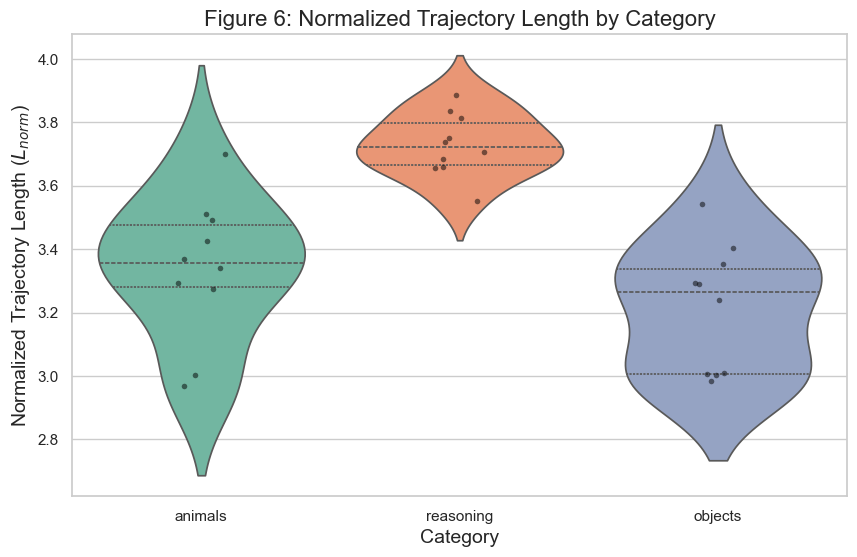

In [6]:
# Plot Figure 6: Normalized Trajectory Length
plt.figure(figsize=(10, 6))
sns.violinplot(data=df, x='group', y='length_norm', hue='group', palette='Set2', legend=False, inner='quartile')
sns.stripplot(data=df, x='group', y='length_norm', color='black', alpha=0.5, size=4, jitter=True)

plt.title('Figure 6: Normalized Trajectory Length by Category', fontsize=16)
plt.xlabel('Category', fontsize=14)
plt.ylabel('Normalized Trajectory Length ($L_{norm}$)', fontsize=14)

os.makedirs('../figures', exist_ok=True)
plt.savefig('../figures/figure6_trajectory_length.pdf', bbox_inches='tight')
plt.savefig('../figures/figure6_trajectory_length.png', bbox_inches='tight', dpi=300)
plt.show()

In [7]:
# Compute Bootstrap CIs and Statistics
groups = ['animals', 'objects', 'reasoning']
ci_results = []

for g in groups:
    group_data = df[df['group'] == g]['length_norm'].values
    mean_val = np.mean(group_data)
    
    # Aggregate across seeds for robust CIs
    lower_bounds, upper_bounds = [], []
    for seed in seeds:
        lb, ub = bootstrap_ci(group_data, num_bootstraps=1000, random_seed=seed)
        lower_bounds.append(lb)
        upper_bounds.append(ub)
        
    ci_results.append({
        'metric': 'length_norm',
        'category': g,
        'mean': mean_val,
        'std': np.std(group_data),
        'ci_lower': np.mean(lower_bounds),
        'ci_upper': np.mean(upper_bounds)
    })

from src.metrics import compute_curvature, compute_convergence_score
if len(trajectories) > 0:
    # Compute Bootstrap CI for Curvature
    # compute_curvature expects all trajectories, but df only has target categories.
    # re-filter trajectories to match df
    target_trajectories = [t for t in trajectories if ((t.prompt.split('_')[0] if hasattr(t, 'group') else str(t.prompt_id).split('_')[0]) in ['animals', 'objects', 'reasoning'] or any(cat in str(t.prompt_id) for cat in ['animal', 'object', 'vehicle', 'reasoning']))]
    target_trajectories = [t for t in target_trajectories if t.prompt_id in df['id'].values]
    curvatures = compute_curvature(target_trajectories)
    df['curvature'] = curvatures
    for g in groups:
        group_data = df[df['group'] == g]['curvature'].values
        mean_val = np.mean(group_data)
        lower_bounds, upper_bounds = [], []
        for seed in seeds:
            lb, ub = bootstrap_ci(group_data, num_bootstraps=1000, random_seed=seed)
            lower_bounds.append(lb)
            upper_bounds.append(ub)
        ci_results.append({
            'metric': 'curvature',
            'category': g,
            'mean': mean_val,
            'std': np.std(group_data),
            'ci_lower': np.mean(lower_bounds),
            'ci_upper': np.mean(upper_bounds)
        })
    
    # Compute Bootstrap CI for Convergence at final layer
    labels = []
    for traj in trajectories:
        if 'animal' in str(traj.prompt_id): labels.append('animals')
        elif 'object' in str(traj.prompt_id) or 'vehicle' in str(traj.prompt_id): labels.append('objects')
        elif 'reasoning' in str(traj.prompt_id): labels.append('reasoning')
        else: labels.append('other')
    scores = compute_convergence_score(trajectories, labels)
    # Convergence is a per-layer score. We bootstrap the final layer convergence score.
    # We can use the pairwise distances directly to bootstrap convergence
    stacked = torch.stack([t.trajectory for t in trajectories]) # [N, L, D]
    dist_l_end = torch.cdist(stacked[:, -1, :], stacked[:, -1, :], p=2).numpy()
    within_lend, between_lend = [], []
    n = len(trajectories)
    for i in range(n):
        for j in range(i + 1, n):
            if labels[i] == labels[j]:
                within_lend.append(dist_l_end[i, j])
            else:
                between_lend.append(dist_l_end[i, j])
    
    mean_between = np.mean(between_lend)
    lb_between, ub_between = [], []
    for seed in seeds:
        lb, ub = bootstrap_ci(np.array(between_lend), num_bootstraps=1000, random_seed=seed)
        lb_between.append(lb)
        ub_between.append(ub)
    ci_results.append({
        'metric': 'convergence_between_dist_final_layer',
        'category': 'global_between',
        'mean': mean_between,
        'std': np.std(between_lend),
        'ci_lower': np.mean(lb_between),
        'ci_upper': np.mean(ub_between)
    })
    
    mean_within = np.mean(within_lend)
    lb_within, ub_within = [], []
    for seed in seeds:
        lb, ub = bootstrap_ci(np.array(within_lend), num_bootstraps=1000, random_seed=seed)
        lb_within.append(lb)
        ub_within.append(ub)
    ci_results.append({
        'metric': 'convergence_within_dist_final_layer',
        'category': 'global_within',
        'mean': mean_within,
        'std': np.std(within_lend),
        'ci_lower': np.mean(lb_within),
        'ci_upper': np.mean(ub_within)
    })

df_ci = pd.DataFrame(ci_results)
df_ci.to_csv('../results/statistics/bootstrap_ci.csv', index=False, mode='w')
print("Bootstrap Confidence Intervals:\n", df_ci)

Bootstrap Confidence Intervals:
                                  metric        category        mean  \
0                           length_norm         animals    3.338123   
1                           length_norm         objects    3.211766   
2                           length_norm       reasoning    3.728744   
3                             curvature         animals    1.089304   
4                             curvature         objects    0.942446   
5                             curvature       reasoning    1.269274   
6  convergence_between_dist_final_layer  global_between  104.757072   
7   convergence_within_dist_final_layer   global_within   87.633995   

         std    ci_lower    ci_upper  
0   0.211551    3.199853    3.463946  
1   0.189080    3.089467    3.329343  
2   0.093957    3.670863    3.786146  
3   0.271912    0.892298    1.232518  
4   0.318696    0.743653    1.136281  
5   0.036667    1.245740    1.291574  
6  71.452919  100.149231  109.416684  
7  61.576267   

In [8]:
# Compute Pairwise Significance Tests
pairs = [('animals', 'objects'), ('animals', 'reasoning'), ('objects', 'reasoning')]
test_results = []

p_values = []
for g1, g2 in pairs:
    data1 = df[df['group'] == g1]['length_norm'].values
    data2 = df[df['group'] == g2]['length_norm'].values
    
    p_val = mann_whitney_u(data1, data2)
    p_values.append(p_val)
    
corrected_p_values = holm_bonferroni_correction(p_values)

for i, (g1, g2) in enumerate(pairs):
    data1 = df[df['group'] == g1]['length_norm'].values
    data2 = df[df['group'] == g2]['length_norm'].values
    
    d = cohens_d(data1, data2)
    
    test_results.append({
        'metric': 'length_norm',
        'comparison': f"{g1}_vs_{g2}",
        'p_value': p_values[i],
        'corrected_p_value': corrected_p_values[i],
        'effect_size': d
    })

df_tests = pd.DataFrame(test_results)
os.makedirs('../results/statistics', exist_ok=True)
df_tests.to_csv('../results/statistics/pairwise_tests.csv', index=False, mode='w')
print("\nPairwise Tests:\n", df_tests)


Pairwise Tests:
         metric            comparison   p_value  corrected_p_value  effect_size
0  length_norm    animals_vs_objects  0.241322           0.241322     0.597484
1  length_norm  animals_vs_reasoning  0.000583           0.001166    -2.264034
2  length_norm  objects_vs_reasoning  0.000183           0.000548    -3.285057


In [9]:
# Generate Markdown Summary Table
with open('../results/statistics/summary_table.md', 'w') as f:
    f.write("# Statistical Summary\n\n")
    f.write("## Bootstrap Confidence Intervals\n\n")
    f.write(df_ci.to_markdown(index=False))
    f.write("\n\n## Pairwise Significance Tests\n\n")
    f.write(df_tests.to_markdown(index=False))
    
print("\nSummary table saved to results/statistics/summary_table.md")


Summary table saved to results/statistics/summary_table.md
